# 🧪Lab: Predicting Seismic Building Response with Support Vector Regression

In this lab, you will practice **Support Vector Machine (SVM)** in the context of **regression**. Over the past two weeks, we have focused on SVM for **classification problems**. However, SVM can also be extended to handle **regression tasks**—this is known as **Support Vector Regression (SVR)**.

To explore this, you will work with the following paper:  https://www.nature.com/articles/s41598-024-81705-3

In this paper, the authors use **real seismic monitoring data** to develop an SVR-based model for predicting the **maximum inter-story drift ratio** of buildings during earthquakes. The authors compare a full-feature model with a reduced-feature version, and demonstrate that SVR is effective in this complex, real-world regression setting.

You will begin by reading the **introduction** of the paper to understand the motivation behind the problem. Later, you will apply Support Vector Regression to their dataset.

Reference:

- Tao, D., Fang, S., Liu, H. et al. Support vector regression model for the prediction of buildings’ maximum seismic response based on real monitoring data. Sci Rep 14, 29874 (2024). https://doi.org/10.1038/s41598-024-81705-3

--- 

**Software**: Use `scikit-learn` and its implementation of Support Vector Regression in this lab. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [2]:
# NAME(s) = "Laine Goldmacher, Edward Max Magrill, and Ashley Qin"

## 1. Paper reflection (10 points)

a. After reading the introduction of the paper, discuss within the group and address the following questions:
   
   - Why is predicting seismic building response important? (You may consider implications for human safety, economic losses, emergency planning, etc)

- Why might the dataset of this study be particularly well-suited for a machine learning approach? (You may think about the volume and diversity of data, the types of features provided, and the limitations of traditional physics-based methods).

Please, elaborate on your answers.

- Predicting seismic building response is important because earthquakes are one of the most destructive kinds of natural disasters. Earthquakes can cause ground shaking, surface rupturing, and ground failure, all of which can destroy buildings and lead to numerous casualties. On top of the human safety aspect, there are an average of 14.7 billion USD per year lost from ground-shaking activities in the US. In order to properly respond in an emergency, it is crucial to assess the seismic damage caused. For these reasons, it is imperative for post-event damage assessment in urban building clusters to rapidly predict the buildings’ maximum seismic responses using the ground motions and incomplete building information.
- The dataset of this study is particularly well-suited for a machine learning approach because it has a wide range of parameters and a high number of observations. The features provided are highly numerical, which is good for machine learning. The features are also quite diverse, ranging from physical features, to material of building, to past events, and earthquakes themselves which helps makes informed predictions. Additionally, the traditional physics-based method is limited by its time consuming nature as well as the amount of resources required, hindering its ability for rapid post-earthquake assessment. Machine learning is a much faster way to process huge amounts of data.

b. After reading the paper, explain, in your own words, how Support Vector Regression (SVR) works. In addition, explain Formulas (1) to (11) from the paper, specifically, what is the intuition behind each equation in light of what we covered in class regarding Support Vector Machine, so you can see the correspondence between SVM for classification and regression.

- Support Vector Regression (SVR) is a supervised learning method for regression tasks. It is a nonlinear regression method that introduces nonlinear kernel to model nonlinear function of multiple variables and uses insensitive loss function to accept small deviation from objective function.
- It identifies support vectors and enables the model to capture the underlying regression function effectively.
- The following formulas explain in depth the process of SVR:
1. $ \left|\mathbf{W}^{T}\Phi(\mathbf{x}_i)+b-y_i\right| \leq \epsilon, \qquad i=1,2,\ldots,n $
   1. Training set: (xi,yi)∈R^n,i=1,2,...,n
   2. xi refers to the vector of characteristic parameters
   3. yi refers to the corresponding true target value
   4. Here,  f(x)=WT·Φ(xi)+b is the linear regression function used to fit the sample data
   5. W is the weighted combination of individual parameters (WT is W transposed)
   6. Φ(xi) is a fixed feature-space transformation of the input xi
   7. b is the intercept
   8. ε is the permissible error, so the absolute value of the linear regression function must be lower than this error for i = 1, 2, ...n. 
2. $ \frac{1}{2}\sum_{i=1}^{n} E_i + \frac{\lambda}{2}\|W\|^2 $
   1. λ is a penalty parameter
   2. $E_i$ is the error between predicted and true value with the tolerance given in equation 3
   3. This formula is the regularized function that we will be aiming to minimize
3. $ E_i = \begin{cases} 0, & |f(x_i) - y_i| \leq \epsilon \\ f(x_i) - y_i - \epsilon, & \text{otherwise} \end{cases} $
   1. This formula explains how we get the error $E_i$, with the tolerance ε
4. $ \frac{1}{2}\|W\|^2 + C\sum_{i=1}^{n}(\xi_i + \xi_i^*) $
   1. Introduces two variables: $\xi_i$ and $\xi_i^*$
   2. $\xi_i$ is the upper slack variable
   3. $\xi_i^*$ is the lower slack variable
   4. The slack variables represent the training errors on the upper and lower sides of the regression function respectively. 
   5. C is a specified constant, also known as the penalty parameter, used to represent the penalty degree of the sample when it exceeds the permissible error
   6. The optimization goal is now to minimize the loss function written as this formula (4)
5. $ \begin{cases} f(x_i) - y_i \leq \epsilon + \xi_i \\ y_i - f(x_i) \leq \epsilon + \xi_i^* \xi_i, \xi_i^* \geq 0 \end{cases} $
    1.  This formula is the condition for the above formula
6. $ L(W,b,\xi,\xi^*,\alpha,\beta,\gamma,\gamma^*) = \frac{1}{2}\|W\|^2 + C\sum_{i=1}^{n}(\xi_i+\xi_i^*) - \sum_{i=1}^{n}\alpha_i(\xi_i+\epsilon-y_i+f(x_i)) - \sum_{i=1}^{n}\beta_i(\xi_i^*+\epsilon+y_i-f(x_i)) - \sum_{i=1}^{n}(\gamma_i\xi_i+\gamma_i^*\xi_i^*) $
    1.  Since Lagrange multiplier method can be used to solve extreme value problems under constrained conditions, formula 4 can be converted into a Lagrangian as shown by this formula (6).
    2.  $\alpha_i$, $\beta_i$, $\gamma_i$, $\gamma_i^*$ are Lagrange multipliers.
    3.  Instead of solving the constrained problem directly, we convert it into a Lagrangian, permitting us to make it unconstrained. We introduce extra multipliers here to incorporate the constraints into the optimization process.
7.  $ W = \sum_{i=1}^{n}(\alpha_i - \beta_i)\Phi(x_i) $
8.  $ \sum_{i=1}^{n}(\alpha_i - \beta_i) = 0 $
9.  $ \alpha_i + \gamma_i = \beta_i + \gamma_i^* = C $
    1.  formulas 7, 8, and 9 are derived by setting the derivative of the above Lagrangian with respect to W, b, $\xi$, and $\xi^*$ to zero.
10. $ b = y_j - W^T \cdot \Phi(x_j) + \epsilon = y_j - \sum_{i=1}^{n}(\alpha_i - \beta_i)k(x_i,x_j) + \epsilon $
    1.  This formula for b can be deduced when we assume $\alpha_i$ > 0
    2.  where $ k(x_i,x_j) = \Phi^T(x_i)\Phi(x_j) $ is the kernel function
11. $ f(x_j) = \sum_{i=1}^{n}(\alpha_i - \beta_i)k(x_i,x_j) + b $
    1.  Finally, we predict $y_j$ from this derived formula

## 2. Exploratory Analysis (15 Points)

a. Load the dataset accompanying this lab and create a new dataset containing the same input features used as predictors in the paper, along with the target variable, *Drift*. **You will use only this new dataset throughout the remainder of the lab.** Display the first few rows of the resulting dataset.

*Hint*: The exact input features used in the predictive framework are clearly specified in the paper. You may also refer to Table 3 to help identify the corresponding features in the provided dataset.

In [9]:
import numpy as np
import pandas as pd

data = pd.read_excel('data_lab02.xlsx', header=[1, 2])

data.columns = [
    f"{col1} {col2}".strip()
    if not str(col2).startswith("Unnamed")
    else str(col1)
    for col1, col2 in data.columns
]

columns = [
    'Height [cm]',
    'No. of story',
    'F1 Hz',
    'PGV [cm/s]',
    'PGD [cm]',
    'Epicentral distance (R) [km]',
    'Magnitude [Mw]',
    'SA1 [cm/s2]',
    'SV1 [cm/s]',
    'SD1 [cm]',
    'Drift [cm/cm]'
]

df = data[columns].copy()

df.head()

,Height [cm],No. of story,F1 Hz,PGV [cm/s],PGD [cm],Epicentral distance (R) [km],Magnitude [Mw],SA1 [cm/s2],SV1 [cm/s],SD1 [cm],Drift [cm/cm]
0,3400.0,8,1.962438,0.073452,0.009969,420.7,5.3,2.800003,0.245024,0.018094,-0.218343
1,3400.0,8,1.834042,0.132411,0.013505,16.6,3.8,2.581543,0.259164,0.019248,-0.226958
2,3400.0,8,1.846080,0.036735,0.003580,132.2,4.2,0.710809,0.083139,0.005131,-0.240754
3,3400.0,8,1.949488,0.026009,0.002277,9.8,3.4,0.578160,0.053573,0.003708,-0.244348
4,3400.0,8,1.778042,1.006804,0.193666,96.6,5.7,12.618900,0.986632,0.099006,-0.101461


b. Explore the distribution of the target variable (Drift), and create scatterplots between Drift and input features.

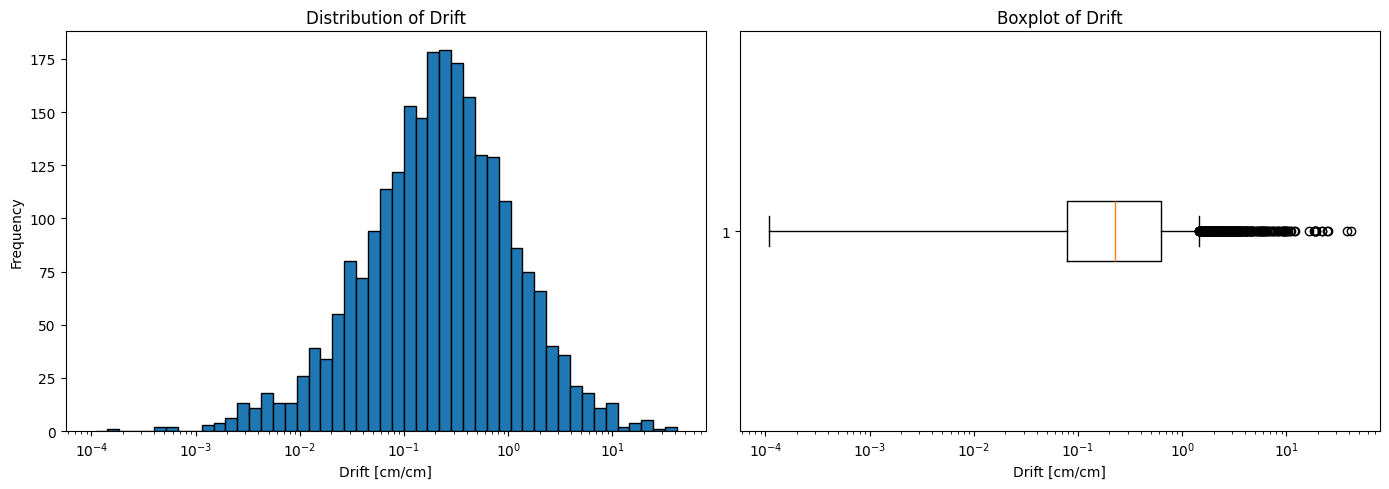

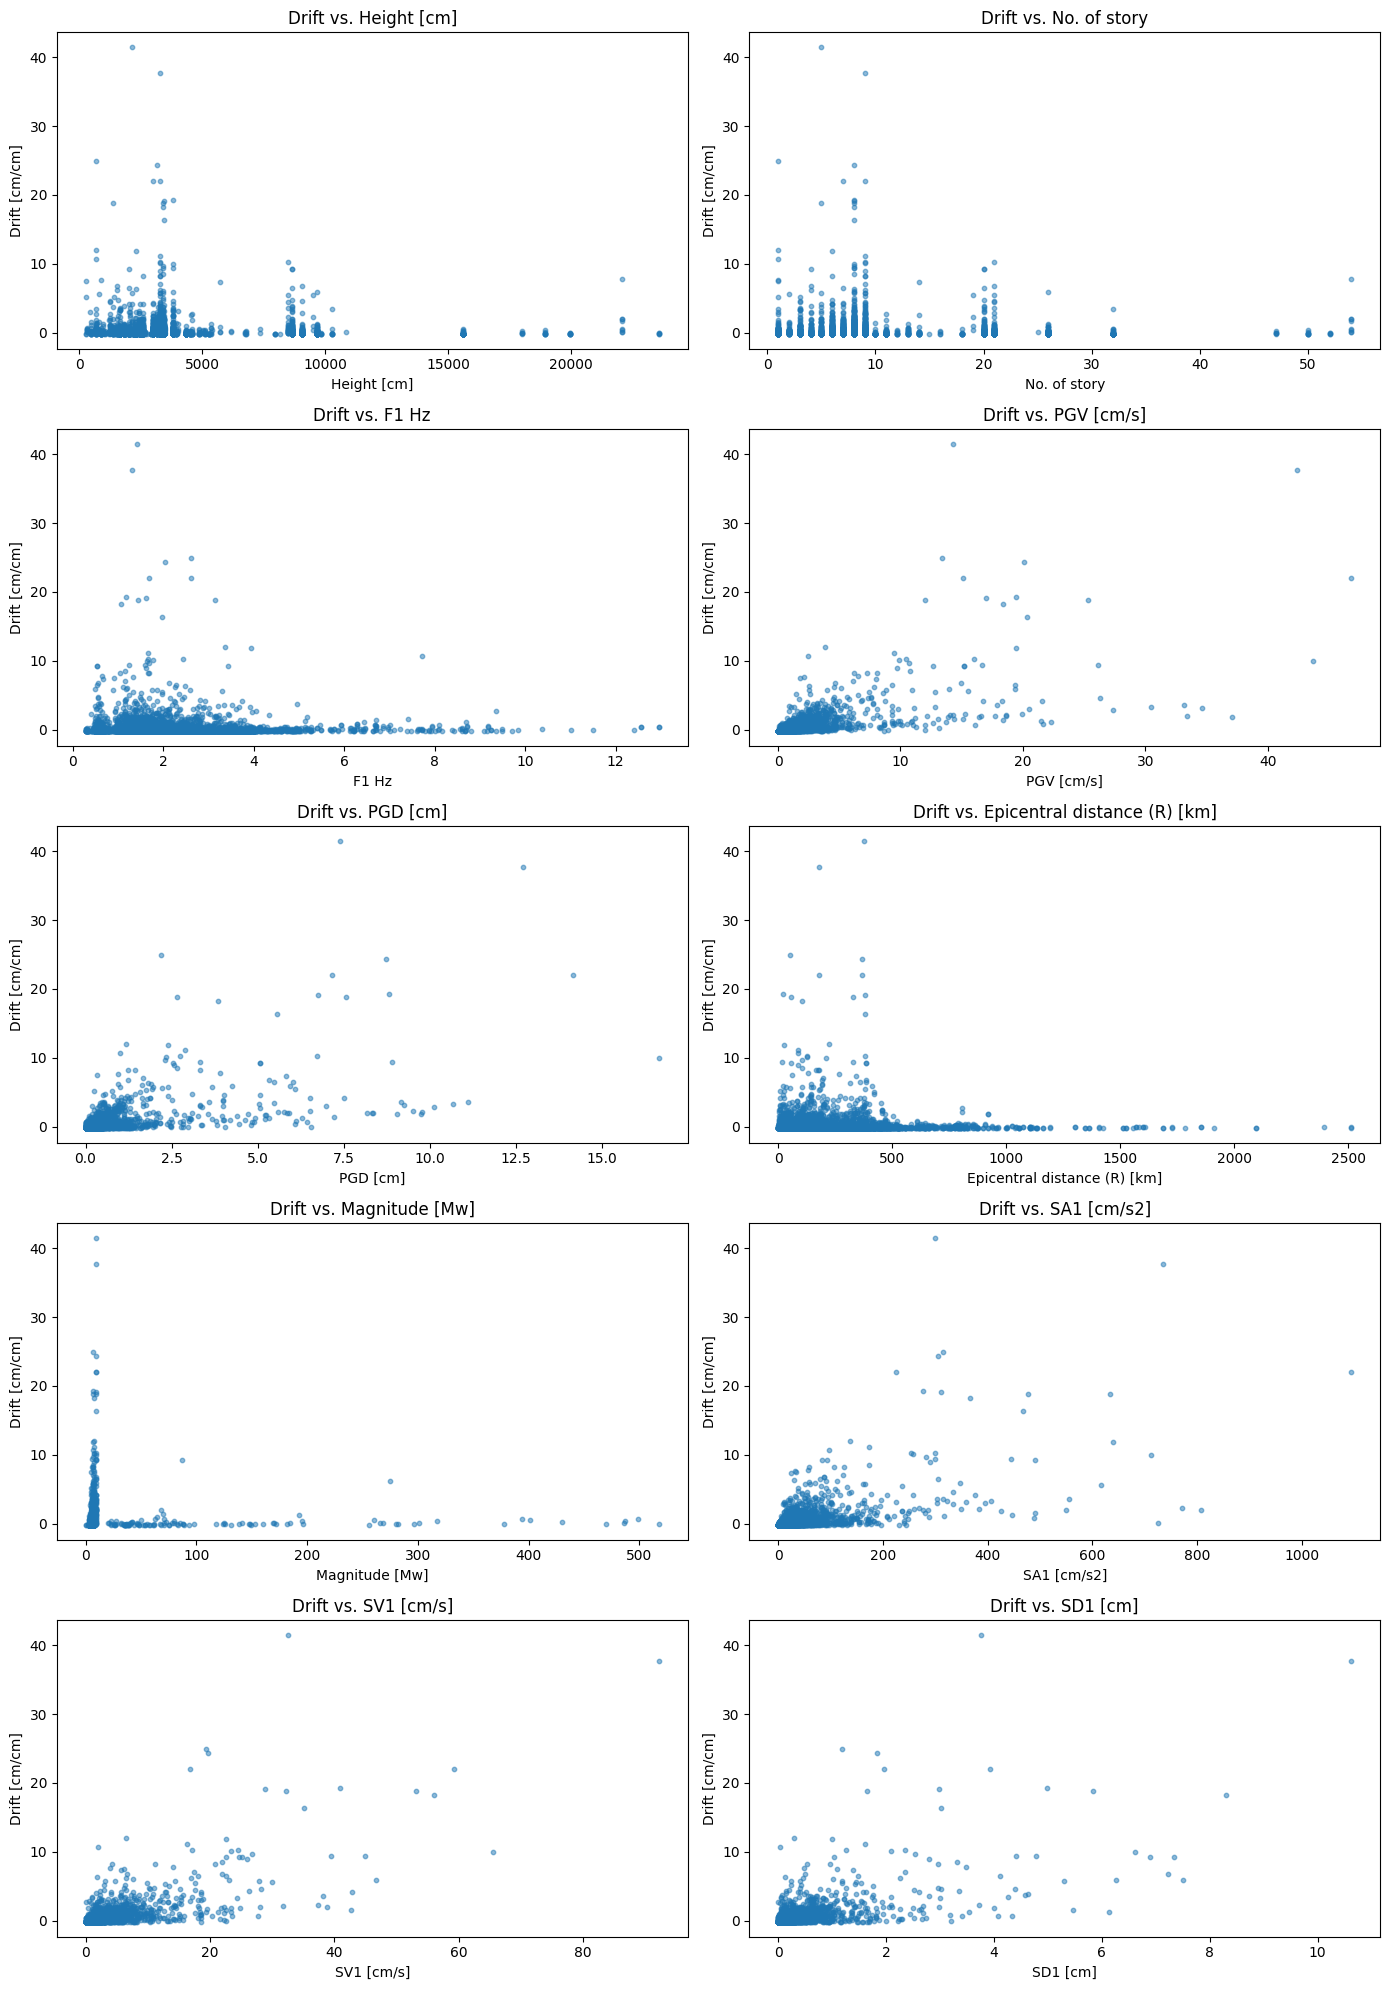

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

drift = df['Drift [cm/cm]'].dropna()
drift = drift[drift > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(drift, bins=np.logspace(
    np.log10(drift.min()),
    np.log10(drift.max()), 50
), edgecolor='black')
axes[0].set_xscale('log')
axes[0].set_xlabel('Drift [cm/cm] (log scale)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Drift')

axes[1].boxplot(drift, vert=False)
axes[1].set_xscale('log')
axes[1].set_xlabel('Drift [cm/cm] (log scale)')
axes[1].set_title('Boxplot of Drift')

plt.tight_layout()
plt.show()
predictors = df.drop(columns=['Drift [cm/cm]']).columns

fig, axes = plt.subplots(5, 2, figsize=(14, 20))

for ax, feature in zip(axes.flatten(), predictors):
    ax.scatter(df[feature], df['Drift [cm/cm]'], alpha=0.5, s=10)
    ax.set_xlabel(feature)
    ax.set_ylabel('Drift [cm/cm]')
    ax.set_title(f'Drift vs. {feature}')

plt.tight_layout()
plt.show()

c. Highlight any particular pattern you observe from the visualizations. Which input features seem potentially more influential in predicting Drift?

YOUR TEXT HERE

## 3. Fit and evaluate (30 points)

a. Fit and evaluate a predictive framework using an SVR model. The process should include automatic tuning of both the kernel and the penalty parameter ((C)). Tune the hyperparameters using cross-validation on the training set, and evaluate the final predictive framework on a separate reporting set. Evaluate its performance using at least the Coefficient of Determination ($R^2$) and Mean Squared Error (MSE).

*N.B.* Remember that a predictive framework may involve more than just the predictive algorithm itself. Consider whether the characteristics of the predictors require any additional steps before fitting the model.

In [ ]:
# [Your code here]

b. Repeat the previous process using an Ridge regression predictive framework. Be sure to include automatic tuning of the model's hyperparameters, specifically, `alpha`.

In [ ]:
# [Your code here]

c. Use predicted vs. true value scatterplots to compare the SVR and Ridge predictive frameworks. Embed performance metrics (e.g., R², MSE) in each plot.

Which predictive framework appears to perform better at this task?

In [ ]:
# [Your code here]

## 4. Reduced SVR Model (30 points)

a. Add a feature selection step to the SVR predictive framework that selects the 10 features most highly correlated with Drift. Retrain  this updated framework and evaluate its performance.

In [ ]:
# [Your code here]

Subsequently, answer the following questions:

- How much does the performance change?
- What are the practical advantages of using this predictive framework with a smaller subset of features?

Elaborate on your answers.

b. Compare the performance of this reduced-feature SVR framework with an optimal Lasso regression framework that uses all available features.

- Do both frameworks select the same features?
- How do their performances compare?

In [ ]:
# [Your code here]

## 5: Robustness to Point Removal (10 points)

a. Compare the sensitivity of SVR and Ridge Regression predictive frameworks to small changes in the training set. To achieve this, randomly remove 10 training points, retrain both predictive frameworks, and assess how much the predictions change.

- Which predictive frameworks appears more stable?
- Why?

In [ ]:
# [Your code here]

## 6. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE